<a href="https://colab.research.google.com/github/LuisVitorVaz/Craindo-meu-rpoprio-jogo/blob/main/cahlenge_telecom_parte_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [3]:
import requests
import json

url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/main/TelecomX_Data.json"

response = requests.get(url)
data = response.json()

df = pd.json_normalize(data)

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [5]:
df.dtypes

,0
customerID,object
Churn,object
customer.gender,object
customer.SeniorCitizen,int64
customer.Partner,object
customer.Dependents,object
customer.tenure,int64
phone.PhoneService,object
phone.MultipleLines,object
internet.InternetService,object


In [6]:
df.describe()


,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly
count,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098
std,0.369074,24.571773,30.129572
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.425000
50%,0.000000,29.000000,70.300000
75%,0.000000,55.000000,89.875000
max,1.000000,72.000000,118.750000


In [7]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df = df.drop_duplicates()

In [10]:
for col in df.select_dtypes(include='object'):
    print(f"\n{col}")
    print(df[col].unique())


customerID
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']

Churn
['No' 'Yes' '']

customer.gender
['Female' 'Male']

customer.Partner
['Yes' 'No']

customer.Dependents
['Yes' 'No']

phone.PhoneService
['Yes' 'No']

phone.MultipleLines
['No' 'Yes' 'No phone service']

internet.InternetService
['DSL' 'Fiber optic' 'No']

internet.OnlineSecurity
['No' 'Yes' 'No internet service']

internet.OnlineBackup
['Yes' 'No' 'No internet service']

internet.DeviceProtection
['No' 'Yes' 'No internet service']

internet.TechSupport
['Yes' 'No' 'No internet service']

internet.StreamingTV
['Yes' 'No' 'No internet service']

internet.StreamingMovies
['No' 'Yes' 'No internet service']

account.Contract
['One year' 'Month-to-month' 'Two year']

account.PaperlessBilling
['Yes' 'No']

account.PaymentMethod
['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']

account.Charges.Total
['593.3' '542.4' '280.85' ... '742.9' '4627.65' '37

In [11]:
df.replace({
    "Yes": 1,
    "No": 0,
    "Sim": 1,
    "Não": 0
}, inplace=True)

/tmp/ipykernel_443/2113762021.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({


In [13]:
df["account.Charges.Total"] = pd.to_numeric(df["account.Charges.Total"], errors="coerce")

In [15]:
df["Contas_Diarias"] = df["account.Charges.Monthly"] / 30

In [16]:
df.describe()

,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,account.PaperlessBilling,account.Charges.Monthly,account.Charges.Total,Contas_Diarias
count,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7256.000000,7267.000000
mean,0.162653,0.484106,0.300124,32.346498,0.902711,0.593230,64.720098,2280.634213,2.157337
std,0.369074,0.499782,0.458343,24.571773,0.296371,0.491265,30.129572,2268.632997,1.004319
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.425000,400.225000,1.180833
50%,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.300000,1391.000000,2.343333
75%,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.875000,3785.300000,2.995833
max,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


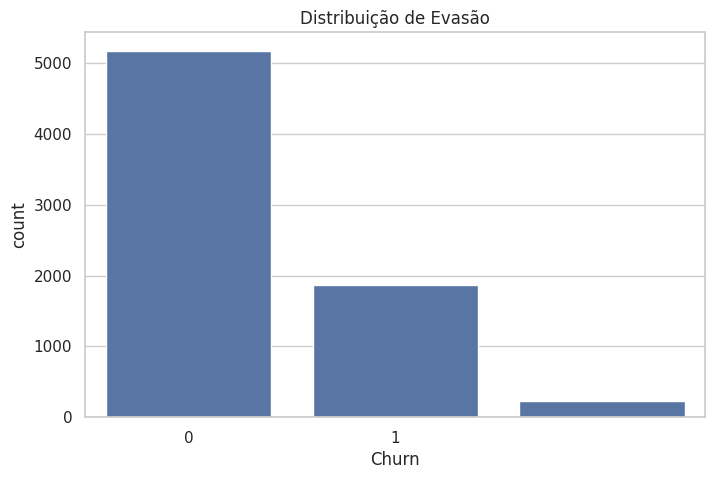

In [17]:
sns.countplot(x="Churn", data=df)
plt.title("Distribuição de Evasão")
plt.show()

In [18]:
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
0,71.198569
1,25.719004
,3.082427


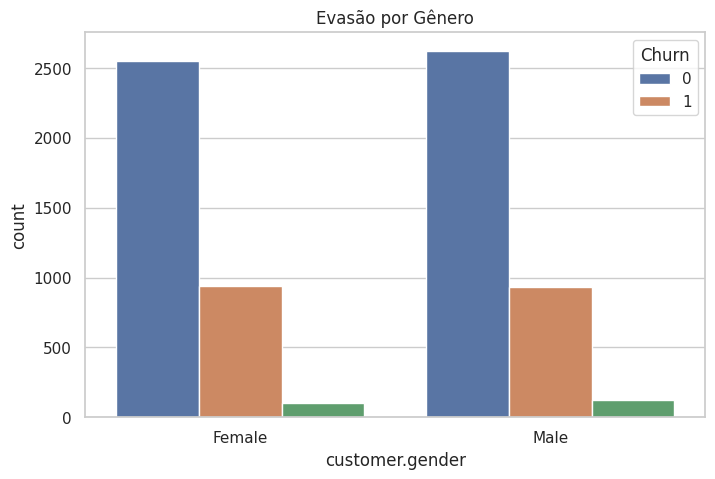

In [20]:
sns.countplot(x="customer.gender", hue="Churn", data=df)
plt.title("Evasão por Gênero")
plt.show()

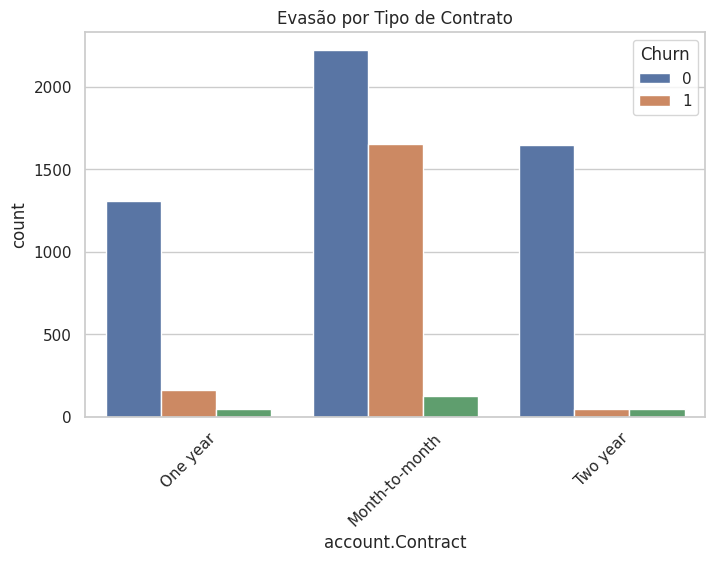

In [22]:
sns.countplot(x="account.Contract", hue="Churn", data=df)
plt.title("Evasão por Tipo de Contrato")
plt.xticks(rotation=45)
plt.show()

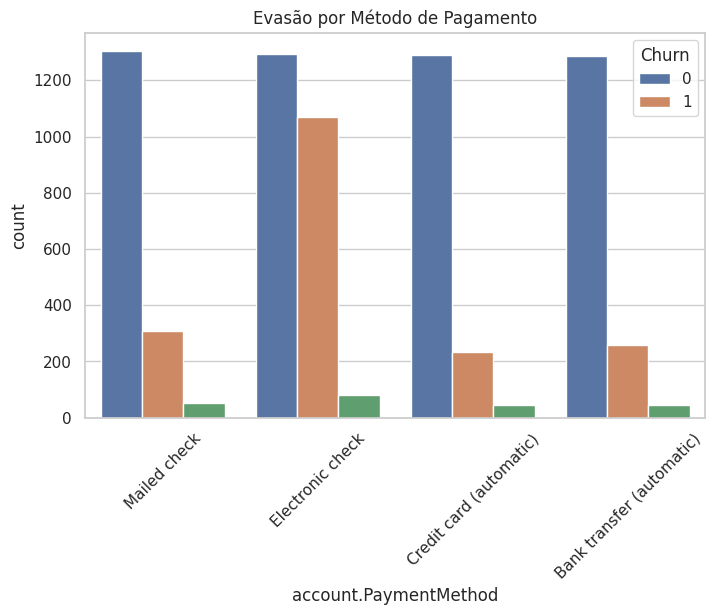

In [24]:
sns.countplot(x="account.PaymentMethod", hue="Churn", data=df)
plt.title("Evasão por Método de Pagamento")
plt.xticks(rotation=45)
plt.show()

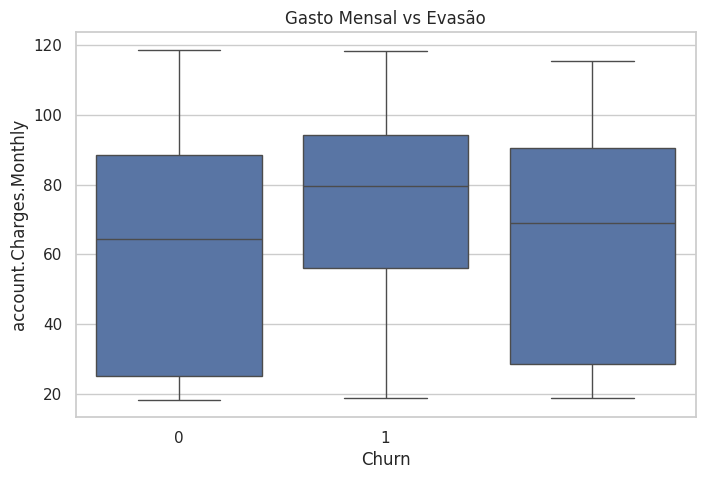

In [27]:
sns.boxplot(x="Churn", y="account.Charges.Monthly", data=df)
plt.title("Gasto Mensal vs Evasão")
plt.show()

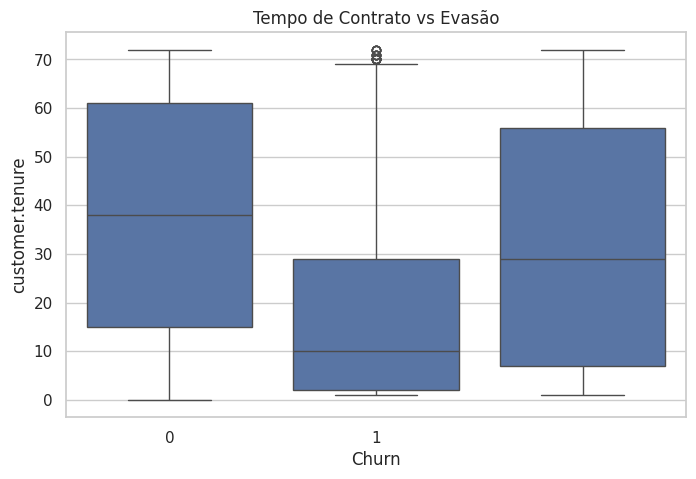

In [28]:
sns.boxplot(x="Churn", y="customer.tenure", data=df)
plt.title("Tempo de Contrato vs Evasão")
plt.show()

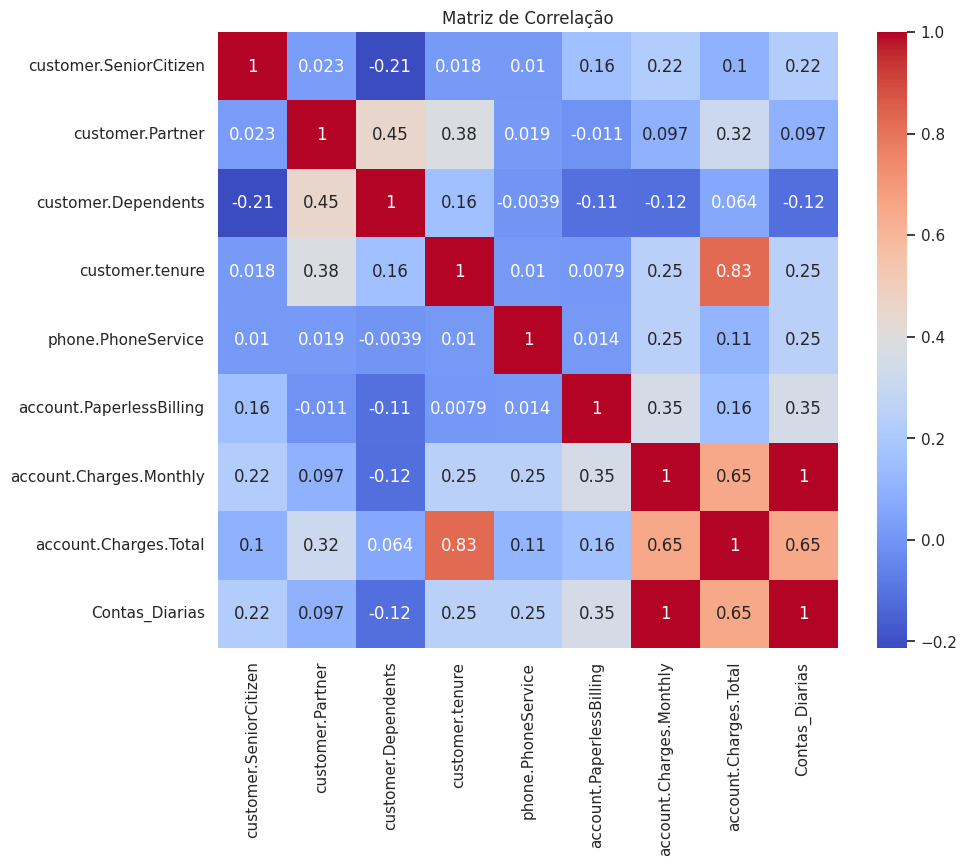

In [29]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()